# Visualisation des cartes d'attention ViT / DINO
Compare les cartes d'attention du dernier bloc (CLS → patches) entre :
- DINO pré-entraîné officiel (Facebook, ViT-S/16)
- Nos checkpoints entraînés sur AQUA20 (`outputs/`)

In [1]:
import sys, os, glob
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
import torchvision.transforms as T

sys.path.insert(0, os.path.abspath('.'))
import vision_transformer as vits

## Config — modifier ici

In [2]:
# Chemin vers l'image à visualiser
IMAGE_PATH = "/home/alex/internship/datasets/aqua20/data/aqua20/test/fish/00414.png"  # ex: "/path/to/image.jpg"

# Taille de resize (doit être divisible par PATCH_SIZE)
IMAGE_SIZE = 224

# Architecture et patch size de nos modèles entraînés
ARCH = "vit_small"
PATCH_SIZE = 16
CHECKPOINT_KEY = "teacher"  # 'teacher' ou 'student'

# Répertoire des outputs
OUTPUTS_DIR = "outputs/"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")



Device: cuda


## Helpers

In [9]:
def load_model_from_checkpoint(checkpoint_path):
    """Charge un ViT depuis un checkpoint DINO (teacher ou student)."""
    model = vits.__dict__[ARCH](patch_size=PATCH_SIZE, num_classes=0)
    ckpt = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    state_dict = ckpt[CHECKPOINT_KEY]
    # Retire les préfixes DDP (module.) et MultiCropWrapper (backbone.)
    state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
    state_dict = {k.replace("backbone.", ""): v for k, v in state_dict.items()}
    msg = model.load_state_dict(state_dict, strict=False)
    epoch = ckpt.get("epoch", "?")
    print(f"  Loaded (epoch {epoch}): {msg}")
    model.eval().to(DEVICE)
    return model, epoch


def load_pretrained_dino():
    """Charge le DINO officiel ViT-S/16 depuis fbaipublicfiles."""
    model = vits.__dict__[ARCH](patch_size=PATCH_SIZE, num_classes=0)
    url = "https://dl.fbaipublicfiles.com/dino/dino_deitsmall16_pretrain/dino_deitsmall16_pretrain.pth"
    state_dict = torch.hub.load_state_dict_from_url(url, map_location="cpu")
    model.load_state_dict(state_dict, strict=True)
    print("  DINO pretrained loaded.")
    model.eval().to(DEVICE)
    return model


def get_attention_maps(model, img_tensor):
    """
    img_tensor: (3, H, W) non-batched
    Retourne (nh, H, W) attention maps upsamplées + (H, W) mean over heads.
    """
    w = img_tensor.shape[1] - img_tensor.shape[1] % PATCH_SIZE
    h = img_tensor.shape[2] - img_tensor.shape[2] % PATCH_SIZE
    img = img_tensor[:, :w, :h].unsqueeze(0).to(DEVICE)

    w_feat = w // PATCH_SIZE
    h_feat = h // PATCH_SIZE

    with torch.no_grad():
        attn = model.get_last_selfattention(img)  # (1, nh, N+1, N+1)

    nh = attn.shape[1]
    # CLS → patch attention
    attn = attn[0, :, 0, 1:].reshape(nh, w_feat, h_feat)  # (nh, wf, hf)
    # Upsample to image size
    attn = nn.functional.interpolate(
        attn.unsqueeze(0), scale_factor=PATCH_SIZE, mode="nearest"
    )[0].cpu().numpy()  # (nh, H, W)

    mean_attn = attn.mean(axis=0)  # (H, W)
    return attn, mean_attn


def preprocess_image(path):
    """Charge et normalise une image. Retourne (tensor, pil_image)."""
    img_pil = Image.open(path).convert("RGB")
    transform = T.Compose([
        T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        T.ToTensor(),
        T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ])
    return transform(img_pil), img_pil.resize((IMAGE_SIZE, IMAGE_SIZE))

## Checkpoints disponibles

In [10]:
all_ckpts = sorted(glob.glob(os.path.join(OUTPUTS_DIR, "*/checkpoint.pth")))
epoch_ckpts = sorted(glob.glob(os.path.join(OUTPUTS_DIR, "*/checkpoint[0-9]*.pth")))

print("Checkpoints finaux:")
for i, p in enumerate(all_ckpts):
    print(f"  [{i}] {p}")

print("\nCheckpoints par époque:")
for i, p in enumerate(epoch_ckpts):
    print(f"  [{i}] {p}")

Checkpoints finaux:
  [0] outputs/dino-aqua20-20260505_120314/checkpoint.pth
  [1] outputs/dino-aqua20-20260505_120658/checkpoint.pth
  [2] outputs/dino-aqua20-20260505_121606/checkpoint.pth
  [3] outputs/dino-aqua20-20260505_122557/checkpoint.pth
  [4] outputs/dino-aqua20-real-20260505_131915/checkpoint.pth
  [5] outputs/dino-no-repeat-aqua20-20260505_180527/checkpoint.pth
  [6] outputs/dino_aqua20/checkpoint.pth
  [7] outputs/dino_aqua20_distilled/checkpoint.pth

Checkpoints par époque:
  [0] outputs/dino-aqua20-20260505_120314/checkpoint0000.pth
  [1] outputs/dino-aqua20-20260505_120658/checkpoint0000.pth
  [2] outputs/dino-aqua20-20260505_121606/checkpoint0000.pth
  [3] outputs/dino-aqua20-20260505_122557/checkpoint0000.pth
  [4] outputs/dino-aqua20-20260505_122557/checkpoint0020.pth
  [5] outputs/dino-aqua20-20260505_122557/checkpoint0040.pth
  [6] outputs/dino-aqua20-real-20260505_131915/checkpoint0000.pth
  [7] outputs/dino-aqua20-real-20260505_131915/checkpoint0020.pth
  [8] ou

## Chargement des modèles
Modifier `selected_checkpoints` pour choisir lesquels comparer.

In [14]:
# Sélectionner les checkpoints à comparer (chemins ou indices de all_ckpts)
selected_checkpoints = [
    all_ckpts[3],
    all_ckpts[4],
    all_ckpts[5],
    
]

models = {}  # label -> model

print("Chargement DINO pretrained...")
models["DINO pretrained"] = load_pretrained_dino()

for ckpt_path in selected_checkpoints:
    label = os.path.basename(os.path.dirname(ckpt_path)) + "/" + os.path.basename(ckpt_path)
    print(f"\nChargement {label}...")
    model, epoch = load_model_from_checkpoint(ckpt_path)
    models[f"{label} (ep{epoch})"] = model

print(f"\n{len(models)} modèles chargés: {list(models.keys())}")

Chargement DINO pretrained...
  DINO pretrained loaded.

Chargement dino-aqua20-20260505_122557/checkpoint.pth...
  Loaded (epoch 60): _IncompatibleKeys(missing_keys=[], unexpected_keys=['head.mlp.0.weight', 'head.mlp.0.bias', 'head.mlp.2.weight', 'head.mlp.2.bias', 'head.mlp.4.weight', 'head.mlp.4.bias', 'head.last_layer.weight_g', 'head.last_layer.weight_v'])

Chargement dino-aqua20-real-20260505_131915/checkpoint.pth...
  Loaded (epoch 23): _IncompatibleKeys(missing_keys=[], unexpected_keys=['head.mlp.0.weight', 'head.mlp.0.bias', 'head.mlp.2.weight', 'head.mlp.2.bias', 'head.mlp.4.weight', 'head.mlp.4.bias', 'head.last_layer.weight_g', 'head.last_layer.weight_v'])

Chargement dino-no-repeat-aqua20-20260505_180527/checkpoint.pth...
  Loaded (epoch 100): _IncompatibleKeys(missing_keys=[], unexpected_keys=['head.mlp.0.weight', 'head.mlp.0.bias', 'head.mlp.2.weight', 'head.mlp.2.bias', 'head.mlp.4.weight', 'head.mlp.4.bias', 'head.last_layer.weight_g', 'head.last_layer.weight_v'])

4 m

## Prétraitement de l'image

Image: /home/alex/internship/datasets/aqua20/data/aqua20/test/fish/00414.png — tensor shape: torch.Size([3, 224, 224])


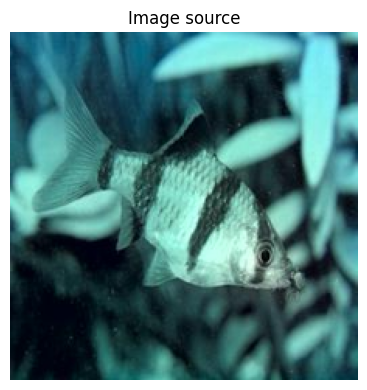

In [15]:
assert IMAGE_PATH, "Renseigner IMAGE_PATH dans la cellule Config"
img_tensor, img_pil = preprocess_image(IMAGE_PATH)
print(f"Image: {IMAGE_PATH} — tensor shape: {img_tensor.shape}")
plt.figure(figsize=(4, 4))
plt.imshow(img_pil)
plt.axis("off")
plt.title("Image source")
plt.tight_layout()
plt.show()

## Visualisation — comparaison des modèles
Chaque ligne = un modèle. Colonnes : image | moyenne des têtes | 6 têtes individuelles.

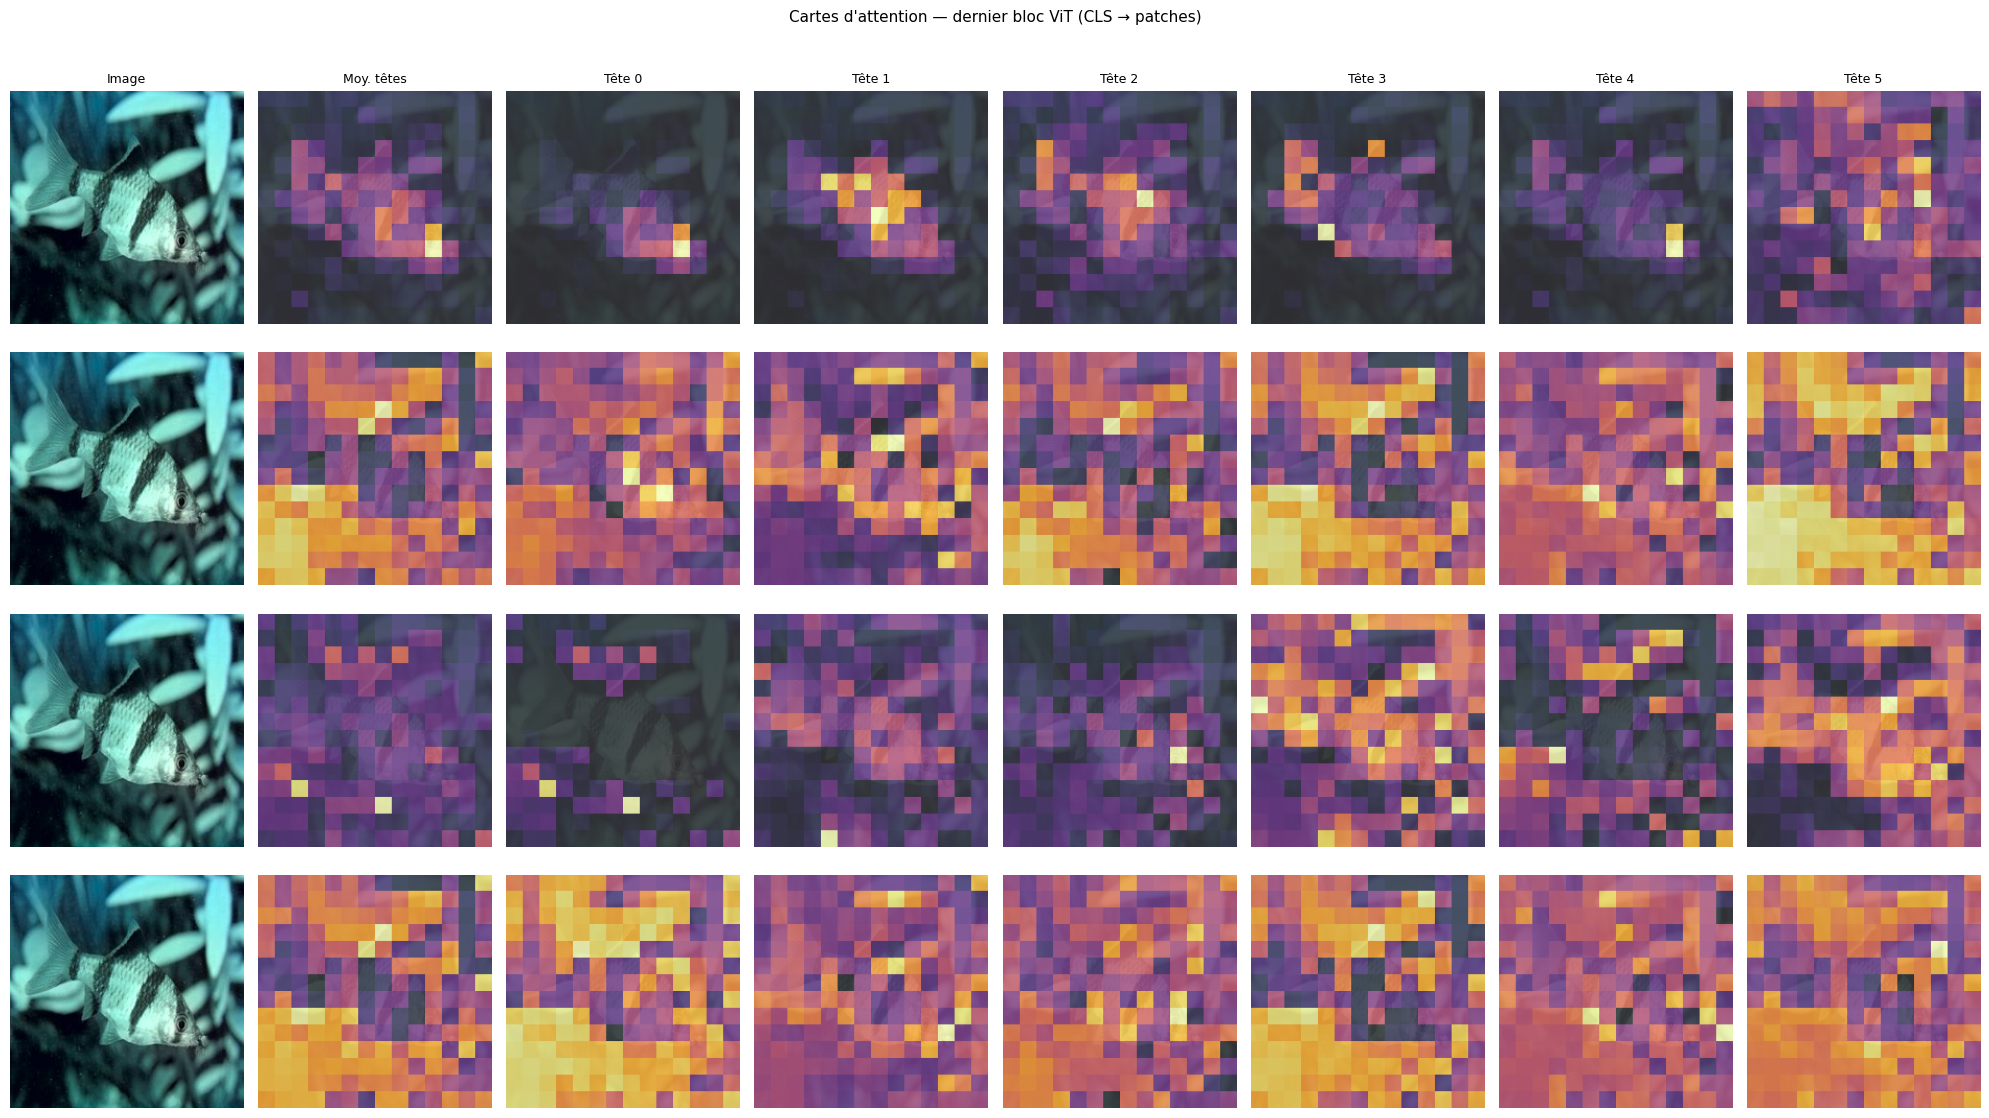

In [ ]:
n_models = len(models)
n_heads = 6  # ViT-Small
n_cols = 2 + n_heads  # image + mean + 6 heads

fig, axes = plt.subplots(n_models, n_cols, figsize=(2.5 * n_cols, 2.8 * n_models))
if n_models == 1:
    axes = axes[np.newaxis, :]

img_np = np.array(img_pil)

for row, (label, model) in enumerate(models.items()):
    head_maps, mean_map = get_attention_maps(model, img_tensor)

    # Col 0 — image originale
    axes[row, 0].imshow(img_np)
    axes[row, 0].axis("off")
    if row == 0:
        axes[row, 0].set_title("Image", fontsize=9)

    # Col 1 — moyenne des têtes
    axes[row, 1].imshow(img_np, alpha=0.4)
    axes[row, 1].imshow(mean_map, cmap="inferno", alpha=0.7)
    axes[row, 1].axis("off")
    if row == 0:
        axes[row, 1].set_title("Moy. têtes", fontsize=9)

    # Cols 2..7 — têtes individuelles
    for h in range(n_heads):
        ax = axes[row, 2 + h]
        ax.imshow(img_np, alpha=0.4)
        ax.imshow(head_maps[h], cmap="inferno", alpha=0.7)
        ax.axis("off")
        if row == 0:
            ax.set_title(f"Tête {h}", fontsize=9)

    # Label du checkpoint à gauche de la rangée
    axes[row, 0].text(
        -0.15, 0.5, label,
        transform=axes[row, 0].transAxes,
        fontsize=8,
        rotation=0,
        ha="right",
        va="center",
        wrap=True,
    )

plt.suptitle("Cartes d'attention — dernier bloc ViT (CLS → patches)", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## Visualisation alternative — overlay superposé pour chaque tête

In [ ]:
def plot_single_model(label, model, img_tensor, img_pil, threshold=None):
    """
    Affiche les cartes d'attention d'un seul modèle.
    threshold: float 0–1, si renseigné affiche uniquement les top-x% de masse d'attention.
    """
    head_maps, mean_map = get_attention_maps(model, img_tensor)
    nh = head_maps.shape[0]
    img_np = np.array(img_pil)

    if threshold is not None:
        # Masque binaire: garde les patches couvrant (1-threshold) de la masse
        thresholded = []
        for h in range(nh):
            flat = head_maps[h].flatten()
            idx = np.argsort(flat)
            cumsum = np.cumsum(flat[idx]) / flat.sum()
            mask = np.zeros_like(flat)
            mask[idx[cumsum >= (1 - threshold)]] = 1
            thresholded.append(mask.reshape(head_maps[h].shape))
        head_maps = np.stack(thresholded)
        mean_map = head_maps.mean(axis=0)

    fig, axes = plt.subplots(2, nh // 2 + 1, figsize=(3 * (nh // 2 + 1), 6))
    axes = axes.flatten()

    axes[0].imshow(img_np)
    axes[0].set_title("Image", fontsize=9)
    axes[0].axis("off")

    for h in range(nh):
        axes[h + 1].imshow(img_np, alpha=0.35)
        axes[h + 1].imshow(head_maps[h], cmap="inferno", alpha=0.75)
        axes[h + 1].set_title(f"Tête {h}", fontsize=9)
        axes[h + 1].axis("off")

    for ax in axes[nh + 1:]:
        ax.axis("off")

    suffix = f" (seuil {threshold:.0%})" if threshold else ""
    plt.suptitle(f"{label}{suffix}", fontsize=10)
    plt.tight_layout()
    plt.show()


# Exemple : afficher un modèle avec seuil à 60%
for label, model in models.items():
    plot_single_model(label, model, img_tensor, img_pil, threshold=0.6)